In this file we try to benchmarking using synthetic gaussian graphical model data.

In [11]:
import numpy as np
from pathlib import Path
import pandas as pd
from typing import Optional

# If you don't have networkx yet:
# !pip install networkx
import networkx as nx


def make_scale_free_graph(p: int, m: int, seed: int = 0) -> nx.Graph:
    """
    Barabási–Albert scale-free graph with p nodes, each new node attaches to m existing nodes.
    Typical: m=2..8. Must satisfy 1 <= m < p.
    """
    if not (1 <= m < p):
        raise ValueError("Need 1 <= m < p")
    return nx.barabasi_albert_graph(n=p, m=m, seed=seed)


def graph_to_precision_omega(
    G: nx.Graph,
    weight_scale: float = 0.2,
    jitter: float = 1e-1,
    seed: int = 0,
) -> np.ndarray:
    """
    Build a symmetric positive definite precision matrix Ω from an undirected graph.

    Construction:
      - Random positive weights w_ij on edges
      - Off-diagonals Ω_ij = Ω_ji = -w_ij  (negative for connected pairs)
      - Diagonal Ω_ii = sum_j |Ω_ij| + jitter  (strict diagonal dominance)
    This guarantees Ω ≻ 0.
    """
    rng = np.random.default_rng(seed)
    p = G.number_of_nodes()

    Omega = np.zeros((p, p), dtype=float)

    # assign random weights to edges
    for i, j in G.edges():
        w = rng.uniform(low=0.05, high=1.0) * weight_scale  # positive weight
        Omega[i, j] = -w
        Omega[j, i] = -w

    # strict diagonal dominance -> SPD
    abs_row_sums = np.sum(np.abs(Omega), axis=1)
    np.fill_diagonal(Omega, abs_row_sums + jitter)

    return Omega


def omega_to_sigma(Omega: np.ndarray) -> np.ndarray:
    """Invert precision to covariance."""
    return np.linalg.inv(Omega)


def sample_gaussian_from_sigma(
    Sigma: np.ndarray,
    n: int,
    seed: int = 0,
    mean: Optional[np.ndarray] = None,
) -> np.ndarray:
    """
    Sample X ~ N(mean, Sigma), returning shape (n, p).
    """
    rng = np.random.default_rng(seed)
    p = Sigma.shape[0]
    if mean is None:
        mean = np.zeros(p)
    return rng.multivariate_normal(mean=mean, cov=Sigma, size=n)


def check_spd(A: np.ndarray, name: str = "A") -> float:
    """Return min eigenvalue (should be > 0)."""
    # For symmetric matrices eigvalsh is stable
    lam_min = np.linalg.eigvalsh(A).min()
    print(f"[CHECK] {name}: min eigenvalue = {lam_min:.6g}")
    return lam_min

def export_for_piglasso(
    X: np.ndarray,
    out_path: Path,
    gene_prefix: str = "G"
):
    """
    Convert sampled matrix X (n x p) to genes x samples TSV.
    """
    n, p = X.shape

    gene_names = [f"{gene_prefix}{i+1}" for i in range(p)]
    sample_names = [f"S{i+1}" for i in range(n)]

    # piglasso expects genes x samples
    df = pd.DataFrame(
        X.T,                 # transpose!
        index=gene_names,
        columns=sample_names
    )

    
    df.to_csv(out_path, sep="\t")

    print(f"[SAVED] {out_path}")
    print(f"Shape (genes x samples): {df.shape}")

    return df

def export_gold_standard(G: nx.Graph, out_path: Path, gene_prefix="G"):
    edges_named = []
    for i, j in G.edges():
        g1 = f"{gene_prefix}{i+1}"
        g2 = f"{gene_prefix}{j+1}"
        edges_named.append((g1, g2))

    df = pd.DataFrame(edges_named, columns=["Gene1", "Gene2"])
    df.to_csv(out_path, sep="\t", index=False)

    print(f"[SAVED] Gold standard: {out_path}")

# ----------------------------
# Example run (edit these)
# ----------------------------
p = 160     # number of genes/nodes
m = 3       # BA parameter (attachments per new node)
n = 1500     # number of samples/experiments

seed_graph = 1
seed_weights = 2
seed_samples = 3

# 1) Choose graph structure (scale-free)
G = make_scale_free_graph(p=p, m=m, seed=seed_graph)

# 2) Convert to precision Ω
Omega = graph_to_precision_omega(G, weight_scale=0.2, jitter=1e-1, seed=seed_weights)

# 3) Ensure Ω ≻ 0 (it should be by construction)
check_spd(Omega, "Omega")

# 4) Invert → Σ
Sigma = omega_to_sigma(Omega)
check_spd(Sigma, "Sigma")  # covariance should also be SPD

# 5) Sample X ~ N(0, Σ)
X = sample_gaussian_from_sigma(Sigma, n=n, seed=seed_samples)

out_file = Path(f"/Users/zoeazra/Documents/CLS/Y2/Thesis/Implementation/BurnInjuries/benchmarking/data/SGG/160/scale_free_{p}_{n}_data.tsv")
export_for_piglasso(X, out_file)
export_gold_standard(G, Path(f"/Users/zoeazra/Documents/CLS/Y2/Thesis/Implementation/BurnInjuries/benchmarking/data/SGG/160/scale_free_{p}_{n}_gold.tsv"))

print("[INFO] X shape:", X.shape)      # (n, p)
print("[INFO] Omega shape:", Omega.shape)
print("[INFO] Sigma shape:", Sigma.shape)

[CHECK] Omega: min eigenvalue = 0.1
[CHECK] Sigma: min eigenvalue = 0.191517
[SAVED] /Users/zoeazra/Documents/CLS/Y2/Thesis/Implementation/BurnInjuries/benchmarking/data/SGG/160/scale_free_160_1500_data.tsv
Shape (genes x samples): (160, 1500)
[SAVED] Gold standard: /Users/zoeazra/Documents/CLS/Y2/Thesis/Implementation/BurnInjuries/benchmarking/data/SGG/160/scale_free_160_1500_gold.tsv
[INFO] X shape: (1500, 160)
[INFO] Omega shape: (160, 160)
[INFO] Sigma shape: (160, 160)


Here we plot some metrics

[INFO] Gold: /Users/zoeazra/Documents/CLS/Y2/Thesis/Implementation/BurnInjuries/benchmarking/data/SGG/160/scale_free_160_1500_gold.tsv
[INFO] Gold undirected edges: 471
[INFO] Piglasso: scale_free_160_1500_data__Q200__bperc0.65__lam0.05-0.3x20__seed52__piglasso_results.pkl

===== RESULTS (Synthetic scale-free) =====
Genes: 160
Candidates: 12720 Positives: 290
AUROC: 0.8841  (random=0.5)
AUPR : 0.3909  (random prevalence=0.0228)
Best F1: 0.5638 at threshold=0.9950
  precision=0.5188, recall=0.6172



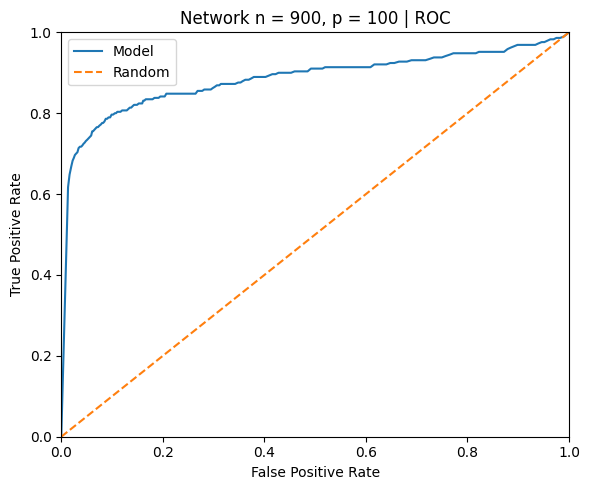

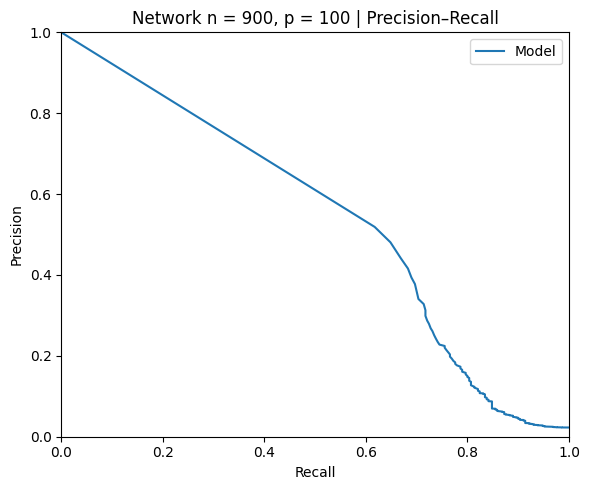

In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score
)

# ----------------------------
# CONFIG (adjust)
# ----------------------------
BENCH_ROOT   = Path("/Users/zoeazra/Documents/CLS/Y2/Thesis/Implementation/BurnInjuries/benchmarking/data/SGG/160")
RESULTS_DIR  = Path("/Users/zoeazra/Documents/CLS/Y2/Thesis/Implementation/BurnInjuries/benchmarking/results/piglasso/SGG/160")
OUT_DIR      = Path("/Users/zoeazra/Documents/CLS/Y2/Thesis/Implementation/BurnInjuries/benchmarking/plots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_FILE = RESULTS_DIR / "scale_free_160_1500_data__Q200__bperc0.65__lam0.05-0.3x20__seed52__piglasso_results.pkl"
GOLD_FILE = BENCH_ROOT / "scale_free_160_1500_gold.tsv"   # change to correct file

PKL_PATH = RESULTS_FILE

if not PKL_PATH.exists():
    raise FileNotFoundError(f"RESULTS_FILE not found: {PKL_PATH}")

if not GOLD_FILE.exists():
    raise FileNotFoundError(f"GOLD_FILE not found: {GOLD_FILE}")

# score aggregation across lambdas
PIG_SCORE_MODE = "max"   # "max" or "mean"


# ----------------------------
# Helpers
# ----------------------------
def load_gold_undirected_edges(gold_path: Path) -> set[tuple[str, str]]:
    df = pd.read_csv(gold_path, sep="\t")
    if df.shape[1] < 2:
        raise ValueError(f"Gold file needs >=2 columns: {gold_path}")
    a = df.iloc[:, 0].astype(str).str.strip()
    b = df.iloc[:, 1].astype(str).str.strip()
    edges = set()
    for i, j in zip(a, b):
        if not i or not j or i == j:
            continue
        edges.add(tuple(sorted((i, j))))
    return edges

def load_piglasso_pkl(pkl_path: Path) -> dict:
    with open(pkl_path, "rb") as f:
        return pickle.load(f)

def piglasso_scores_from_payload(payload: dict, mode: str = "max") -> tuple[list[str], np.ndarray]:
    """
    payload["edge_counts_all"] shape: (p, p, L)
    payload["success_counts"] shape: (L,)
    returns (genes, score_mat) where score_mat is p x p, directed scores in [0,1]
    """
    E = np.array(payload["edge_counts_all"], dtype=float)      # (p,p,L)
    succ = np.array(payload["success_counts"], dtype=float)    # (L,)
    genes = list(map(str, payload["genes"]))

    succ = np.where(succ <= 0, np.nan, succ)
    S = E / succ.reshape(1, 1, -1)  # stability per lambda

    if mode == "max":
        score_mat = np.nanmax(S, axis=2)
    elif mode == "mean":
        score_mat = np.nanmean(S, axis=2)
    else:
        raise ValueError("mode must be 'max' or 'mean'")

    np.fill_diagonal(score_mat, 0.0)
    score_mat = np.nan_to_num(score_mat, nan=0.0)

    return genes, score_mat

def build_undirected_pred_scores(genes: list[str], score_mat: np.ndarray) -> dict[tuple[str, str], float]:
    """
    Convert directed p x p score matrix into undirected edge scores:
      score({i,j}) = max(score(i,j), score(j,i))
    """
    pred = {}
    p = len(genes)
    for i in range(p):
        for j in range(i+1, p):
            g1, g2 = genes[i], genes[j]
            pred[(g1, g2)] = float(max(score_mat[i, j], score_mat[j, i]))
    return pred

def evaluate_undirected_all_pairs(
    genes: list[str],
    pred_scores: dict[tuple[str, str], float],
    gold_edges: set[tuple[str, str]],
):
    """
    Universe = all undirected gene pairs among 'genes' (excluding self loops).
    """
    y_true, y_score = [], []
    n_candidates = 0
    n_pos = 0

    p = len(genes)
    for i in range(p):
        for j in range(i+1, p):
            e = (genes[i], genes[j])  # already i<j in construction
            n_candidates += 1
            label = 1 if e in gold_edges else 0
            n_pos += label
            y_true.append(label)
            y_score.append(pred_scores.get(e, 0.0))

    y_true = np.array(y_true, dtype=int)
    y_score = np.array(y_score, dtype=float)

    auroc = roc_auc_score(y_true, y_score)
    aupr = average_precision_score(y_true, y_score)

    prevalence = n_pos / n_candidates if n_candidates else 0.0

    return {
        "y_true": y_true,
        "y_score": y_score,
        "auroc": float(auroc),
        "aupr": float(aupr),
        "auroc_random": 0.5,
        "aupr_random": float(prevalence),
        "n_candidates": int(n_candidates),
        "n_pos": int(n_pos),
    }

def best_f1_from_pr(y_true: np.ndarray, y_score: np.ndarray):
    """
    Compute PR curve and return best F1 over thresholds.
    sklearn returns:
      precision: len = T+1
      recall:    len = T+1
      thresh:    len = T
    We'll align by using precision[1:], recall[1:] with thresh.
    """
    precision, recall, thresh = precision_recall_curve(y_true, y_score)

    # avoid div by 0
    f1 = (2 * precision * recall) / np.clip((precision + recall), 1e-12, None)

    # threshold-aligned indices are 1..end-1 (precision[0] corresponds to thresh missing)
    if len(thresh) == 0:
        return {"best_f1": float(f1.max()), "threshold": None, "precision": None, "recall": None}

    f1_t = f1[1:]  # aligns with thresh
    p_t  = precision[1:]
    r_t  = recall[1:]

    k = int(np.nanargmax(f1_t))
    return {
        "best_f1": float(f1_t[k]),
        "threshold": float(thresh[k]),
        "precision": float(p_t[k]),
        "recall": float(r_t[k]),
    }

def plot_roc_pr(y_true: np.ndarray, y_score: np.ndarray, title: str):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    prec, rec, _ = precision_recall_curve(y_true, y_score)

    # ROC
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label="Model")
    plt.plot([0,1],[0,1], linestyle="--", label="Random")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title} | ROC")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # PR
    plt.figure(figsize=(6,5))
    plt.plot(rec, prec, label="Model")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title} | Precision–Recall")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ----------------------------
# RUN
# ----------------------------
print("[INFO] Gold:", GOLD_FILE)
gold_edges = load_gold_undirected_edges(GOLD_FILE)
print(f"[INFO] Gold undirected edges: {len(gold_edges)}")

print("[INFO] Piglasso:", PKL_PATH.name)
payload = load_piglasso_pkl(PKL_PATH)
genes, score_mat = piglasso_scores_from_payload(payload, mode=PIG_SCORE_MODE)

pred_scores = build_undirected_pred_scores(genes, score_mat)

# IMPORTANT: restrict gold to your gene set (in case)
gene_set = set(genes)
gold_edges = {e for e in gold_edges if e[0] in gene_set and e[1] in gene_set}

res = evaluate_undirected_all_pairs(genes, pred_scores, gold_edges)
f1res = best_f1_from_pr(res["y_true"], res["y_score"])

print("\n===== RESULTS (Synthetic scale-free) =====")
print("Genes:", len(genes))
print("Candidates:", res["n_candidates"], "Positives:", res["n_pos"])
print(f"AUROC: {res['auroc']:.4f}  (random={res['auroc_random']})")
print(f"AUPR : {res['aupr']:.4f}  (random prevalence={res['aupr_random']:.4f})")
print(f"Best F1: {f1res['best_f1']:.4f} at threshold={f1res['threshold']:.4f}")
print(f"  precision={f1res['precision']:.4f}, recall={f1res['recall']:.4f}")
print("=========================================\n")

plot_roc_pr(res["y_true"], res["y_score"], title="Network n = 900, p = 100")

Creating another PRAUC plot with error bars

In [42]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_auc_score


# ----------------------------
# CONFIG
# ----------------------------
PROJECT_ROOT = Path("/Users/zoeazra/Documents/CLS/Y2/Thesis/Implementation/BurnInjuries")

RESULTS_DIR = PROJECT_ROOT / "benchmarking" / "results" / "piglasso" / "SGG" / "160"
GOLD_DIR    = PROJECT_ROOT / "benchmarking" / "data" / "SGG" / "160"
OUT_DIR     = PROJECT_ROOT / "benchmarking" / "plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PIG_SCORE_MODE = "max"   # "max" or "mean"

# error bar mode: "std", "sem", or "ci95"
ERRORBAR_MODE = "std"


# ----------------------------
# Helpers
# ----------------------------
def load_gold_undirected_edges(gold_path: Path) -> set[tuple[str, str]]:
    df = pd.read_csv(gold_path, sep="\t")
    if df.shape[1] < 2:
        raise ValueError(f"Gold file needs >=2 columns: {gold_path}")

    a = df.iloc[:, 0].astype(str).str.strip().str.upper()
    b = df.iloc[:, 1].astype(str).str.strip().str.upper()

    edges = set()
    for i, j in zip(a, b):
        if not i or not j or i == j:
            continue
        edges.add(tuple(sorted((i, j))))
    return edges


def load_piglasso_pkl(pkl_path: Path) -> dict:
    with open(pkl_path, "rb") as f:
        return pickle.load(f)


def piglasso_scores_from_payload(payload: dict, mode: str = "max") -> tuple[list[str], np.ndarray]:
    E = np.array(payload["edge_counts_all"], dtype=float)      # (p,p,L)
    succ = np.array(payload["success_counts"], dtype=float)    # (L,)
    genes = [str(g).strip().upper() for g in payload["genes"]]

    succ = np.where(succ <= 0, np.nan, succ)
    S = E / succ.reshape(1, 1, -1)

    if mode == "max":
        score_mat = np.nanmax(S, axis=2)
    elif mode == "mean":
        score_mat = np.nanmean(S, axis=2)
    else:
        raise ValueError("mode must be 'max' or 'mean'")

    np.fill_diagonal(score_mat, 0.0)
    score_mat = np.nan_to_num(score_mat, nan=0.0)

    return genes, score_mat


def build_undirected_pred_scores(genes: list[str], score_mat: np.ndarray) -> dict[tuple[str, str], float]:
    pred = {}
    p = len(genes)
    for i in range(p):
        for j in range(i + 1, p):
            g1, g2 = genes[i], genes[j]
            pred[(g1, g2)] = float(max(score_mat[i, j], score_mat[j, i]))
    return pred


def evaluate_undirected_all_pairs(
    genes: list[str],
    pred_scores: dict[tuple[str, str], float],
    gold_edges: set[tuple[str, str]],
):
    y_true, y_score = [], []
    n_candidates = 0
    n_pos = 0

    p = len(genes)
    for i in range(p):
        for j in range(i + 1, p):
            e = (genes[i], genes[j])
            n_candidates += 1
            label = 1 if e in gold_edges else 0
            n_pos += label
            y_true.append(label)
            y_score.append(pred_scores.get(e, 0.0))

    y_true = np.array(y_true, dtype=int)
    y_score = np.array(y_score, dtype=float)

    aupr = average_precision_score(y_true, y_score)
    prevalence = n_pos / n_candidates if n_candidates else 0.0
    auroc = roc_auc_score(y_true, y_score)

    return {
        "aupr": float(aupr),
        "auroc": float(auroc),
        "aupr_random": float(prevalence),
        "n_candidates": int(n_candidates),
        "n_pos": int(n_pos),
    }


def parse_pkl_info(pkl_name: str):
    """
    Expected something like:
    scale_free_160_100_data__Q200__...__seed3__piglasso_results.pkl

    Returns dict with p, n, seed if found.
    """
    info = {"p": None, "n": None, "seed": None}

    m = re.search(r"scale_free_(\d+)_(\d+)_data", pkl_name)
    if m:
        info["p"] = int(m.group(1))
        info["n"] = int(m.group(2))

    m_seed = re.search(r"__seed(\d+)", pkl_name)
    if m_seed:
        info["seed"] = int(m_seed.group(1))

    return info


def make_gold_path(p: int, n: int) -> Path:
    return GOLD_DIR / f"scale_free_{p}_{n}_gold.tsv"


# ----------------------------
# Collect all runs
# ----------------------------
pkl_files = sorted(RESULTS_DIR.glob("*.pkl"))
if not pkl_files:
    raise FileNotFoundError(f"No .pkl files found in {RESULTS_DIR}")

rows = []

for pkl_path in pkl_files:
    info = parse_pkl_info(pkl_path.name)

    if info["p"] is None or info["n"] is None:
        print(f"[SKIP] Could not parse p/n from filename: {pkl_path.name}")
        continue

    gold_path = make_gold_path(info["p"], info["n"])
    if not gold_path.exists():
        print(f"[SKIP] Gold file not found for {pkl_path.name}: {gold_path.name}")
        continue

    payload = load_piglasso_pkl(pkl_path)
    genes, score_mat = piglasso_scores_from_payload(payload, mode=PIG_SCORE_MODE)
    pred_scores = build_undirected_pred_scores(genes, score_mat)

    gold_edges = load_gold_undirected_edges(gold_path)

    # restrict gold to inferred gene set
    gene_set = set(genes)
    gold_edges = {e for e in gold_edges if e[0] in gene_set and e[1] in gene_set}

    res = evaluate_undirected_all_pairs(genes, pred_scores, gold_edges)

    rows.append({
        "file": pkl_path.name,
        "p": info["p"],
        "n": info["n"],
        "seed": info["seed"],
        "aupr": res["aupr"],
        "auroc": res["auroc"],   # ← ADD THIS
        "aupr_random": res["aupr_random"],
        "n_candidates": res["n_candidates"],
        "n_pos": res["n_pos"],
    })

results_df = pd.DataFrame(rows)

if results_df.empty:
    raise RuntimeError("No benchmark results could be parsed.")

display(results_df.head())

,file,p,n,seed,aupr,auroc,aupr_random,n_candidates,n_pos
0,scale_free_160_100_data__Q200__bperc0.65__lam0...,160,100,42,0.068478,0.542359,0.022799,12720,290
1,scale_free_160_100_data__Q200__bperc0.65__lam0...,160,100,43,0.069252,0.538752,0.022799,12720,290
2,scale_free_160_100_data__Q200__bperc0.65__lam0...,160,100,44,0.063201,0.539114,0.022799,12720,290
3,scale_free_160_100_data__Q200__bperc0.65__lam0...,160,100,45,0.068419,0.541241,0.022799,12720,290
4,scale_free_160_100_data__Q200__bperc0.65__lam0...,160,100,46,0.069905,0.541415,0.022799,12720,290


In [43]:
summary_df = (
    results_df
    .groupby(["p", "n"], as_index=False)["aupr"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

summary_df["sem"] = summary_df["std"] / np.sqrt(summary_df["count"])

if ERRORBAR_MODE == "std":
    summary_df["err"] = summary_df["std"]
elif ERRORBAR_MODE == "sem":
    summary_df["err"] = summary_df["sem"]
elif ERRORBAR_MODE == "ci95":
    summary_df["err"] = 1.96 * summary_df["sem"]
else:
    raise ValueError("ERRORBAR_MODE must be 'std', 'sem', or 'ci95'")

display(summary_df)

,index,p,n,mean,std,count,sem,err
0,0,160,100,0.068341,0.002609,11,0.000787,0.002609
1,1,160,300,0.172320,0.004267,11,0.001287,0.004267
2,2,160,500,0.238249,0.004632,11,0.001396,0.004632
3,3,160,700,0.295831,0.005056,11,0.001524,0.005056
4,4,160,900,0.319988,0.005027,11,0.001516,0.005027
5,5,160,1100,0.342750,0.005596,11,0.001687,0.005596
6,6,160,1300,0.365680,0.005631,11,0.001698,0.005631
7,7,160,1500,0.388909,0.005633,11,0.001698,0.005633


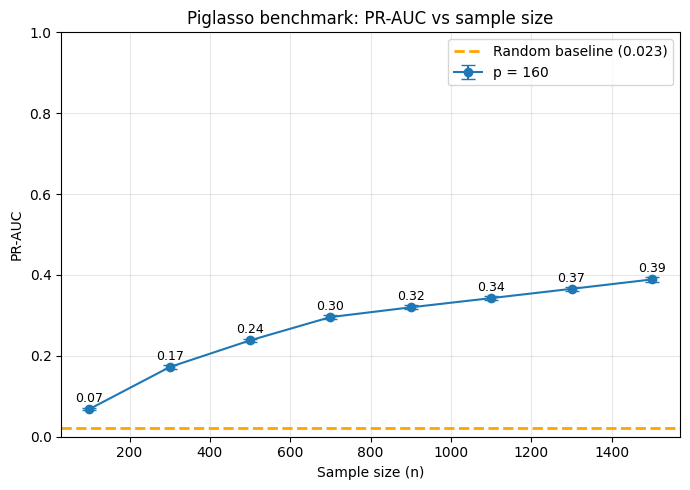

In [46]:
plt.figure(figsize=(7, 5))

for p_val in sorted(summary_df["p"].unique()):
    sub = summary_df[summary_df["p"] == p_val].sort_values("n")

    plt.errorbar(
        sub["n"],
        sub["mean"],
        yerr=sub["err"],
        marker="o",
        capsize=5,
        elinewidth=1.5,
        label=f"p = {p_val}"
    )
# ---- ADD TEXT LABELS ----
for x, y in zip(sub["n"], sub["mean"]):
    plt.text(
        x,
        y + 0.01,                    # small vertical offset
        f"{y:.2f}",                  # 2 decimals
        ha="center",
        va="bottom",
        fontsize=9
    )
# ---- ADD RANDOM BASELINE ----
# take mean baseline across runs (or just first — should be constant per p)
baseline = results_df["aupr_random"].mean()

plt.axhline(
    y=baseline,
    linestyle="--",
    linewidth=2,
    color= 'orange',
    label=f"Random baseline ({baseline:.3f})"
)

# ----------------------------

plt.xlabel("Sample size (n)")
plt.ylabel("PR-AUC")
plt.title("Piglasso benchmark: PR-AUC vs sample size")
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
# ----------------------------
# Aggregate AUROC
# ----------------------------
summary_auc = (
    results_df
    .groupby(["p", "n"], as_index=False)["auroc"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

summary_auc["sem"] = summary_auc["std"] / np.sqrt(summary_auc["count"])

# choose error bar type
ERRORBAR_MODE = "ci95"  # "std", "sem", or "ci95"

if ERRORBAR_MODE == "std":
    summary_auc["err"] = summary_auc["std"]
elif ERRORBAR_MODE == "sem":
    summary_auc["err"] = summary_auc["sem"]
elif ERRORBAR_MODE == "ci95":
    summary_auc["err"] = 1.96 * summary_auc["sem"]
else:
    raise ValueError("ERRORBAR_MODE must be 'std', 'sem', or 'ci95'")

display(summary_auc)


,index,p,n,mean,std,count,sem,err
0,0,160,100,0.541076,0.001694,11,0.000511,0.001001
1,1,160,300,0.696514,0.001286,11,0.000388,0.000760
2,2,160,500,0.768609,0.000951,11,0.000287,0.000562
3,3,160,700,0.799793,0.000752,11,0.000227,0.000444
4,4,160,900,0.830763,0.001070,11,0.000323,0.000632
5,5,160,1100,0.860079,0.001420,11,0.000428,0.000839
6,6,160,1300,0.870467,0.000695,11,0.000209,0.000411
7,7,160,1500,0.884517,0.000591,11,0.000178,0.000349


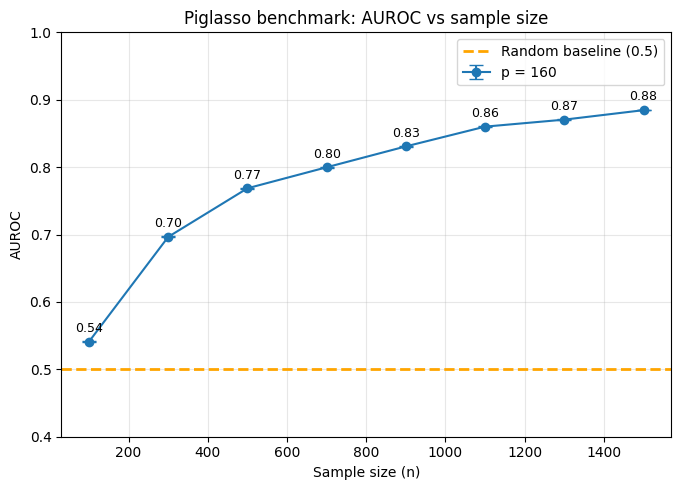

In [40]:
plt.figure(figsize=(7, 5))

for p_val in sorted(summary_auc["p"].unique()):
    sub = summary_auc[summary_auc["p"] == p_val].sort_values("n")

    # plot line + error bars
    plt.errorbar(
        sub["n"],
        sub["mean"],
        yerr=sub["err"],
        marker="o",
        capsize=5,
        elinewidth=1.5,
        label=f"p = {p_val}"
    )

    # ---- ADD TEXT LABELS ----
    for x, y in zip(sub["n"], sub["mean"]):
        plt.text(
            x,
            y + 0.01,                    # small vertical offset
            f"{y:.2f}",                  # 2 decimals
            ha="center",
            va="bottom",
            fontsize=9
        )

# ---- Random baseline ----
plt.axhline(
    y=0.5,
    linestyle="--",
    linewidth=2,
    color="orange",
    label="Random baseline (0.5)"
)

plt.xlabel("Sample size (n)")
plt.ylabel("AUROC")
plt.title("Piglasso benchmark: AUROC vs sample size")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(0.4, 1)

plt.show()